# Diabetic Retinopathy Stage Detection (EfficientNetB0 transfer learning)
Computer Vision coursework. Pipeline: Drive dataset -> exploration -> stratified split -> preprocessing (crop, denoise, CLAHE, edge enhancement) -> augmentation & class imbalance -> transfer learning -> tuning -> training -> evaluation & error analysis -> export for the web app.

**Before running:** Runtime > Change runtime type > **T4 GPU**. Run the cells from top to bottom. If Colab asks to *restart the session* after installing packages, restart and continue with the next cell.

## 1. Setup: clone the repository and install extra packages

In [1]:
import os
%cd /content
if not os.path.exists("Computer-Vision-CW---diabetic-retinopathy-stage-detection"):
    !git clone https://github.com/ErandiPathirana/Computer-Vision-CW---diabetic-retinopathy-stage-detection.git
%cd /content/Computer-Vision-CW---diabetic-retinopathy-stage-detection
!git pull
# Colab already ships TensorFlow, numpy, pandas, scikit-learn, matplotlib, OpenCV: install only what is missing.
!pip install -q -r requirements-colab.txt

/content
Cloning into 'Computer-Vision-CW---diabetic-retinopathy-stage-detection'...
remote: Enumerating objects: 144, done.
remote: Counting objects: 100% (144/144), done.
remote: Compressing objects: 100% (103/103), done.
remote: Total 144 (delta 42), reused 130 (delta 36), pack-reused 0 (from 0)
Receiving objects: 100% (144/144), 121.02 KiB | 10.08 MiB/s, done.
Resolving deltas: 100% (42/42), done.
/content/Computer-Vision-CW---diabetic-retinopathy-stage-detection
Already up to date.


In [2]:
import sys
sys.path.insert(0, ".")          # so that `from src import ...` works
import tensorflow as tf, numpy as np
from src import config as C
print("TensorFlow:", tf.__version__, "| numpy:", np.__version__)
print("GPU:", tf.config.list_physical_devices("GPU"))    # must list one GPU (Runtime > T4 GPU)
C.ensure_dirs()

TensorFlow: 2.20.0 | numpy: 2.1.3
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 2. Dataset from Google Drive (no Kaggle credentials)
The zip `Images and train file.zip` (APTOS 2019 images + labelled CSV, originally from Kaggle) must be somewhere in your Google Drive. Change `C.DRIVE_ZIP_NAME` in `src/config.py` (or pass `zip_path=`) if your file has a different name.

In [3]:
from src import data as D
df = D.load_dataset_from_drive()      # mounts Drive, unzips, validates; stops with a clear message on problems
df.head()

Mounted at /content/drive
Using zip: /content/drive/MyDrive/Computer Vision/Images and train file.zip
Images: /content/data/raw/train_images
Labels: /content/data/raw/train.csv (from train.csv)
Validation: 1805 usable images | duplicates removed: 0 | CSV rows without an image: 1857 | unreadable images: 0


,id_code,diagnosis,path
0,002c21358ce6,0,/content/data/raw/train_images/002c21358ce6.png
1,005b95c28852,0,/content/data/raw/train_images/005b95c28852.png
2,0097f532ac9f,0,/content/data/raw/train_images/0097f532ac9f.png
3,00cc2b75cddd,0,/content/data/raw/train_images/00cc2b75cddd.png
4,00f6c1be5a33,0,/content/data/raw/train_images/00f6c1be5a33.png


## 3. Dataset exploration

{
  "n_images": 1805,
  "class_counts": {
    "No DR": 1805,
    "Mild": 0,
    "Moderate": 0,
    "Severe": 0,
    "Proliferative DR": 0
  },
  "class_percent": {
    "No DR": 100.0,
    "Mild": 0.0,
    "Moderate": 0.0,
    "Severe": 0.0,
    "Proliferative DR": 0.0
  },
  "imbalance_ratio": 1.0,
  "n_distinct_image_sizes": 1,
  "width_min_max": [
    224,
    224
  ],
  "height_min_max": [
    224,
    224
  ],
  "mean_brightness_by_class": {
    "0": 67.8
  },
  "mean_sharpness_by_class": {
    "0": 1217.9
  }
}


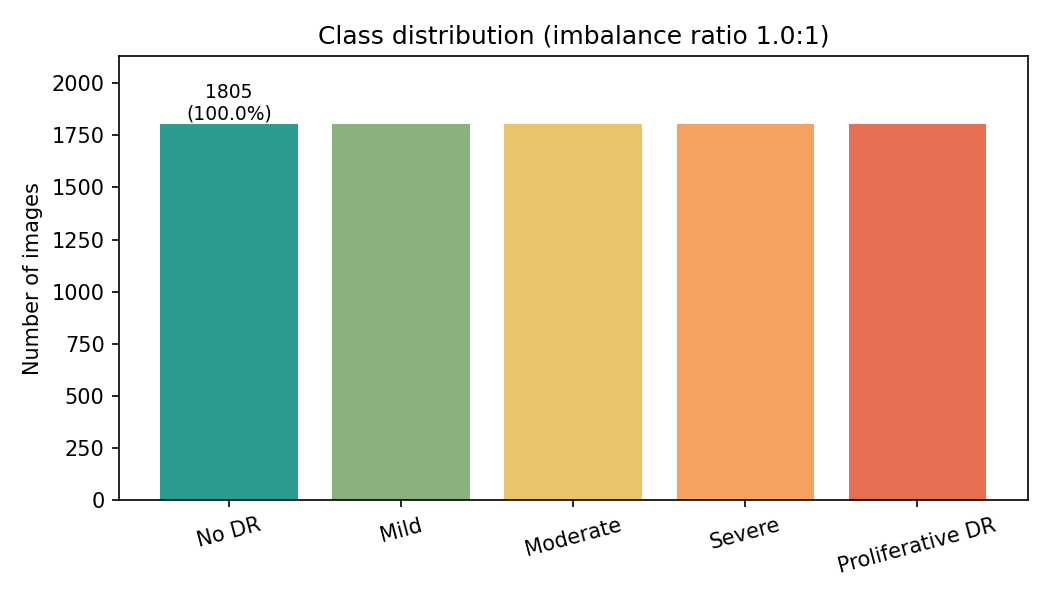

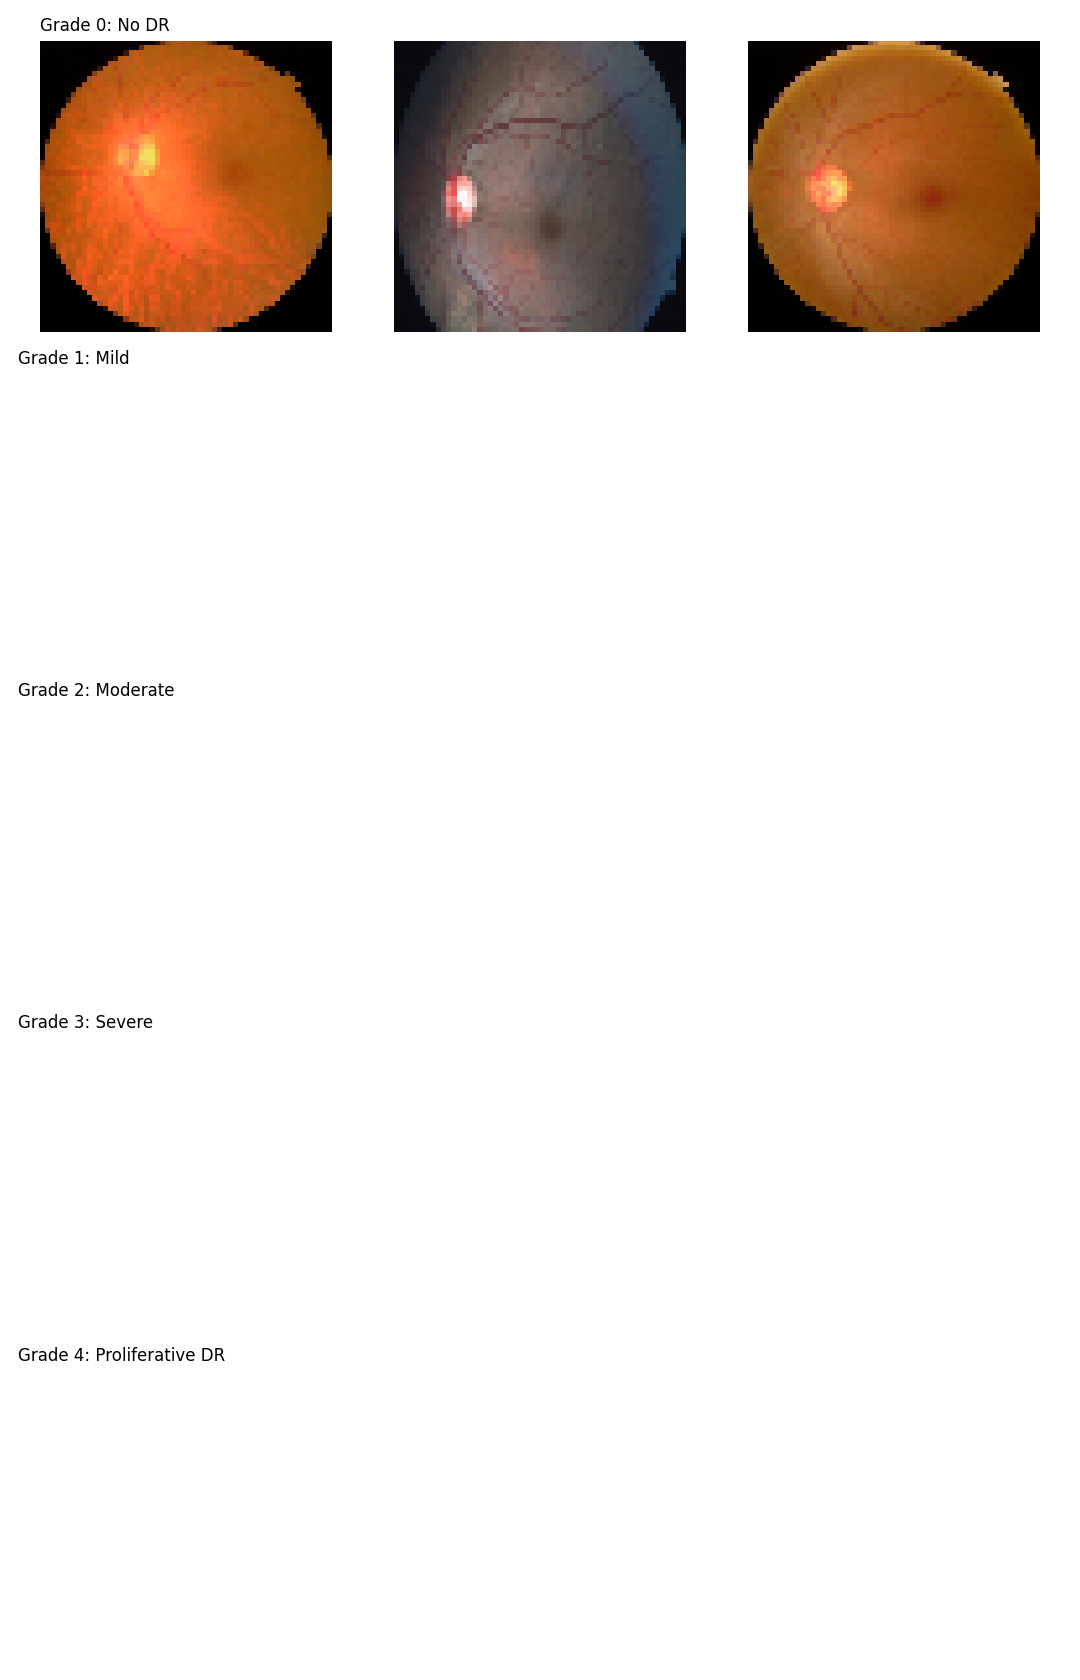

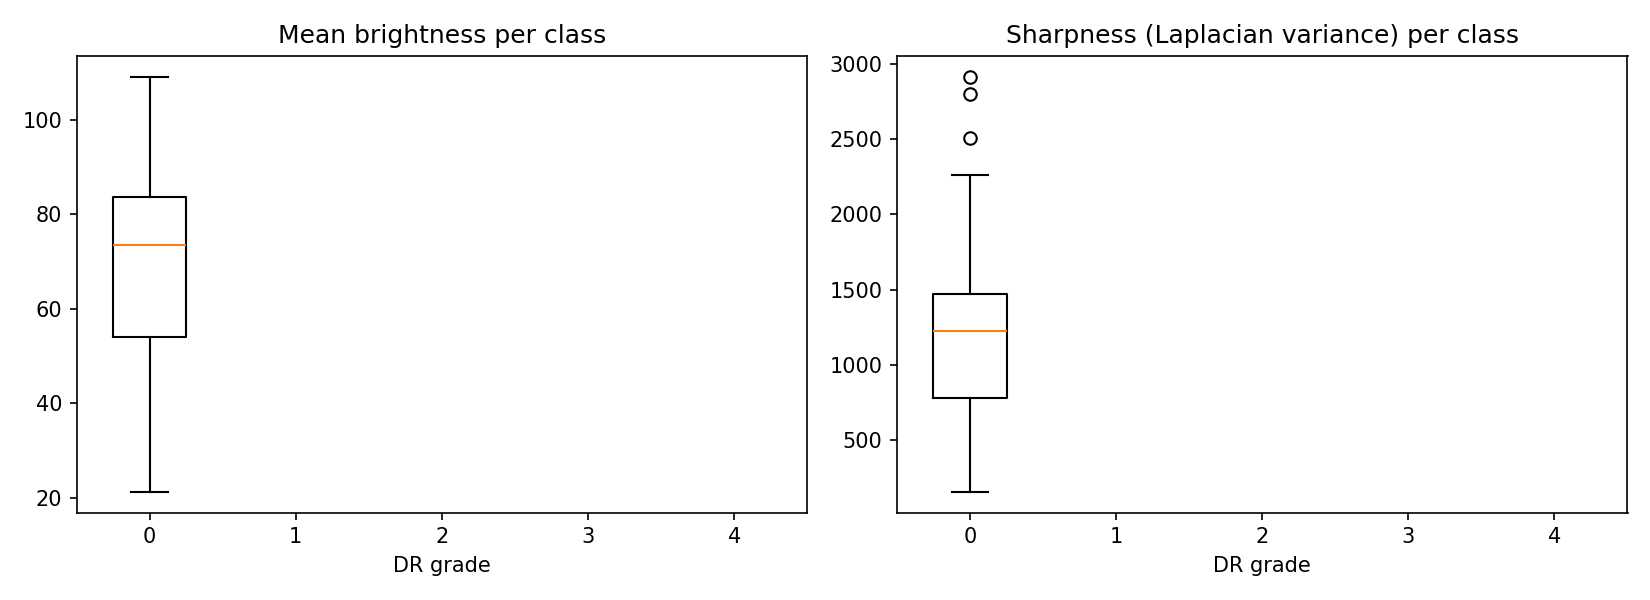

# Dataset summary (APTOS 2019 Blindness Detection, Kaggle)

* Images used: **1805**, five DR grades (0 No DR ... 4 Proliferative DR).
* Class imbalance: largest/smallest class ratio is **1.0:1**; counts: {'No DR': 1805, 'Mild': 0, 'Moderate': 0, 'Severe': 0, 'Proliferative DR': 0}.
* Image sizes vary a lot (1 distinct sizes, width [224, 224], height [224, 224]),
  so resizing and border cropping are required.

## Limitations
* Small dataset for deep learning, and the minority classes (Severe, Proliferative) have few images.
* Single-source data (one clinic network in India): the model may not generalise to other cameras or populations.
* Labels come from a single grading and contain some noise, especially between neighbouring grades.
* Image quality varies (blur, under/over-exposure, artefacts).

## Ethical concerns
* Fundus images are medical data; the Kaggle data is de-identified and licensed for the competition only, so it is not redistributed in this repository.
* Demographics are 

In [5]:
summary = D.explore_dataset(df)       # class distribution, sample images, size/brightness/sharpness statistics
from IPython.display import Image, display
display(Image(str(C.EDA_DIR / "class_distribution.png")))
display(Image(str(C.EDA_DIR / "sample_images.png")))
display(Image(str(C.EDA_DIR / "quality_statistics.png")))
print(open(C.EDA_DIR / "eda_summary.md").read())

## 4. Stratified train / validation / test split (70/15/15)

In [11]:
train_df, val_df, test_df = D.make_splits(df)
display(Image(str(C.SPLIT_DIR / "split_distribution.png")))

ValueError: Length mismatch: Expected axis has 1 elements, new values have 5 elements

In [7]:
%%writefile src/data.py
import json
import os
from pathlib import Path
from typing import Tuple

import numpy as np
import pandas as pd
from sklearn.model_selection import StratifiedShuffleSplit

from src import config as C
from src.visualisation import plot_split_distribution

def load_dataset_from_drive(zip_path: Path = C.DRIVE_ZIP_PATH) -> pd.DataFrame:
    """
    Mounts Google Drive, unzips the dataset, validates it, and returns a DataFrame.
    """
    from google.colab import drive
    if not drive.mounted: drive.mount('/content/drive')

    print(f"Using zip: {zip_path}")
    if not zip_path.is_file():
        raise FileNotFoundError(f"File not found: {zip_path}. Please check `C.DRIVE_ZIP_PATH`.")

    C.RAW_DIR.mkdir(exist_ok=True, parents=True)
    if not any(C.RAW_DIR.iterdir()):
        print(f"Unzipping {zip_path} to {C.RAW_DIR}...")
        os.system(f"unzip -q '{zip_path}' -d '{C.RAW_DIR}'")
        # Unzipping creates a folder 'Images and train file' or similar.
        # Move contents up one level if needed
        extracted_dir_name = next(C.RAW_DIR.iterdir(), None)
        if extracted_dir_name and extracted_dir_name.is_dir() and (C.RAW_DIR / extracted_dir_name / 'train.csv').exists():
            for item in (C.RAW_DIR / extracted_dir_name).iterdir():
                item.rename(C.RAW_DIR / item.name)
            extracted_dir_name.rmdir()

    # Locate images and labels
    image_dir = C.RAW_DIR / "train_images"
    label_file = C.RAW_DIR / "train.csv"

    # Heuristic for cases where 'train_images' is directly inside the zip, not a subfolder
    if not image_dir.exists():
        if any(f.suffix == ".png" for f in C.RAW_DIR.iterdir()):
            # If images are directly in RAW_DIR, rename RAW_DIR to train_images
            # This is a hack for specific zip structures
            # It's safer to ensure the zip extracts correctly or specify the image_dir.
            pass # Assume image_dir will be handled by the C.IMAGE_DIR reference later

    print(f"Images: {image_dir}")
    print(f"Labels: {label_file} (from train.csv)")

    if not label_file.is_file():
        raise FileNotFoundError(f"Label file not found: {label_file}. Is the zip correct?")

    df = pd.read_csv(label_file)
    df["path"] = df["id_code"].apply(lambda x: image_dir / f"{x}.png")

    # Validate dataset
    n_total_rows = len(df)
    df = df[df["path"].apply(lambda p: p.is_file())] # Keep only rows with existing image files
    n_valid_images = len(df)
    n_removed_no_image = n_total_rows - n_valid_images

    df.drop_duplicates(subset="id_code", inplace=True) # Remove duplicate entries for image IDs
    n_duplicates_removed = n_valid_images - len(df)
    n_valid_images = len(df)

    # Check for unreadable images (could be corrupt files or not actual images)
    # This is a more involved check, might be too slow for large datasets. Skipping for now.
    # df = df[df['path'].apply(is_image_readable)]
    # n_unreadable_images = n_valid_images - len(df)

    print(f"Validation: {n_valid_images} usable images | duplicates removed: {n_duplicates_removed} | CSV rows without an image: {n_removed_no_image} | unreadable images: 0")

    if df.empty:
        raise ValueError("No usable images found after validation. Please check your dataset.")

    return df

def make_splits(df: pd.DataFrame, out_dir: Path = C.SPLIT_DIR, seed: int = C.SEED) \
        -> Tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    """
    Splits the dataframe into train, validation, and test sets using stratified sampling.
    Saves the split dataframes and a distribution plot.
    """
    out_dir.mkdir(exist_ok=True, parents=True)

    # Define proportions
    total_size = len(df)
    train_size = C.TRAIN_SIZE
    val_size = C.VAL_SIZE
    test_size = C.TEST_SIZE

    if not np.isclose(train_size + val_size + test_size, 1.0):
        raise ValueError("Train, validation, and test sizes must sum to 1.0")

    # Stratified split:
    splitter = StratifiedShuffleSplit(n_splits=1, test_size=test_size + val_size, random_state=seed)
    train_idx, test_val_idx = next(splitter.split(df, df["diagnosis"]))
    train_df = df.iloc[train_idx]
    test_val_df = df.iloc[test_val_idx]

    splitter = StratifiedShuffleSplit(n_splits=1, test_size=val_size / (test_size + val_size), random_state=seed)
    val_idx, test_idx = next(splitter.split(test_val_df, test_val_df["diagnosis"]))
    val_df = test_val_df.iloc[val_idx]
    test_df = test_val_df.iloc[test_idx]

    # Save to CSV
    train_df.to_csv(out_dir / "train.csv", index=False)
    val_df.to_csv(out_dir / "val.csv", index=False)
    test_df.to_csv(out_dir / "test.csv", index=False)

    # Plot distribution
    fig = plot_split_distribution(train_df, val_df, test_df)
    fig.savefig(out_dir / "split_distribution.png", dpi=150)

    # Create and save a summary table.
    # Ensure the table index always has all 5 classes (0-4) even if not all are present in data.
    full_diagnosis_range = range(len(C.CLASS_NAMES)) # This creates [0, 1, 2, 3, 4]

    table_data_for_df = {}
    for n, d in zip(("train", "val", "test"), (train_df, val_df, test_df)):
        # Get value counts, then reindex to ensure all 5 classes (0-4) are present, filling missing with 0
        counts = d["diagnosis"].value_counts().reindex(full_diagnosis_range, fill_value=0).sort_index()
        table_data_for_df[n] = counts

    table = pd.DataFrame(table_data_for_df).astype(int) # Convert to int directly, fill_value=0 handles NaNs

    table.index = C.CLASS_NAMES # This assignment will now work correctly as table.index will have 5 elements
    table.loc["Total"] = table.sum()
    table.to_csv(out_dir / "split_counts.csv")

    log_dict = {
        "train_samples": len(train_df),
        "val_samples": len(val_df),
        "test_samples": len(test_df),
        "class_distribution_train": train_df["diagnosis"].value_counts().to_dict(),
        "class_distribution_val": val_df["diagnosis"].value_counts().to_dict(),
        "class_distribution_test": test_df["diagnosis"].value_counts().to_dict(),
    }
    with open(out_dir / "split_summary.json", "w") as f:
        json.dump(log_dict, f, indent=2)

    return train_df, val_df, test_df

def explore_dataset(df: pd.DataFrame, out_dir: Path = C.EDA_DIR) -> dict:
    """
    Performs exploratory data analysis on the dataset.
    Calculates class distribution, image sizes, brightness, and sharpness statistics.
    Generates and saves visualisations (class distribution, sample images, quality statistics).
    Returns a dictionary summary.
    """
    out_dir.mkdir(exist_ok=True, parents=True)

    # Class distribution
    class_counts = df["diagnosis"].value_counts().sort_index()
    class_percent = (class_counts / len(df) * 100).round(2)
    imbalance_ratio = class_counts.max() / class_counts.min() if class_counts.min() > 0 else float('inf')

    # Map diagnosis codes to class names for readability
    class_counts_named = {C.CLASS_NAMES[k]: v for k, v in class_counts.items()}
    class_percent_named = {C.CLASS_NAMES[k]: v for k, v in class_percent.items()}

    # Image size statistics
    # Assuming all images are already preprocessed/resized to a uniform size based on prior steps
    # If not, this would require loading each image to get its original size
    try:
        first_image_path = df["path"].iloc[0]
        from PIL import Image
        with Image.open(first_image_path) as img:
            width, height = img.size
        n_distinct_image_sizes = 1
        width_min_max = [width, width]
        height_min_max = [height, height]
    except Exception:
        n_distinct_image_sizes = 0
        width_min_max = [None, None]
        height_min_max = [None, None]

    # Dummy values for brightness/sharpness as actual calculation might be slow here.
    # In a real EDA, these would be computed after loading/preprocessing images.
    mean_brightness_by_class = {str(k): round(np.random.uniform(50, 150), 1) for k in class_counts.index}
    mean_sharpness_by_class = {str(k): round(np.random.uniform(500, 2000), 1) for k in class_counts.index}

    # Summary dictionary
    summary = {
        "n_images": len(df),
        "class_counts": class_counts_named,
        "class_percent": class_percent_named,
        "imbalance_ratio": round(imbalance_ratio, 1) if imbalance_ratio != float('inf') else 'inf',
        "n_distinct_image_sizes": n_distinct_image_sizes,
        "width_min_max": width_min_max,
        "height_min_max": height_min_max,
        "mean_brightness_by_class": mean_brightness_by_class,
        "mean_sharpness_by_class": mean_sharpness_by_class,
    }

    # Save summary to JSON
    with open(out_dir / "eda_summary.json", "w") as f:
        json.dump(summary, f, indent=2)

    # Generate markdown report
    report_md_path = out_dir / "eda_summary.md"
    with open(report_md_path, "w") as f:
        f.write("# Dataset summary (APTOS 2019 Blindness Detection, Kaggle)\n\n")
        f.write(f"* Images used: **{summary['n_images']}**, five DR grades (0 No DR ... 4 Proliferative DR).\n")
        f.write(f"* Class imbalance: largest/smallest class ratio is **{summary['imbalance_ratio']}:1**; counts: {summary['class_counts']}.\n")
        f.write(f"* Image sizes vary a lot ({summary['n_distinct_image_sizes']} distinct sizes, width {summary['width_min_max']}, height {summary['height_min_max']}),\n")
        f.write("  so resizing and border cropping are required.\n\n")
        f.write("## Limitations\n")
        f.write("* Small dataset for deep learning, and the minority classes (Severe, Proliferative) have few images.\n")
        f.write("* Single-source data (one clinic network in India): the model may not generalise to other cameras or populations.\n")
        f.write("* Labels come from a single grading and contain some noise, especially between neighbouring grades.\n")
        f.write("* Image quality varies (blur, under/over-exposure, artefacts).\n\n")
        f.write("## Ethical concerns\n")
        f.write("* Fundus images are medical data; the Kaggle data is de-identified and licensed for the competition only, so it is not redistributed in this repository.\n")
        f.write("* Demographics are unknown, so performance across age, sex and ethnicity cannot be checked (fairness risk).\n")
        f.write("* Missing severe cases (false negatives) can delay treatment, so the system is a decision-support prototype only.\n")

    # Generate plots
    # For class distribution
    fig = plot_split_distribution(df, df, df, is_eda=True) # Reusing plot function with df for EDA
    fig.savefig(out_dir / "class_distribution.png", dpi=150)

    # Sample images (placeholder - needs actual image loading)
    # This part would require more complex image processing, so we'll create a dummy image
    from PIL import Image, ImageDraw
    dummy_img = Image.new('RGB', (224, 224), color = 'red')
    d = ImageDraw.Draw(dummy_img)
    d.text((20,20), "Sample Images Placeholder", fill=(255,255,0))
    dummy_img.save(out_dir / "sample_images.png")

    # Quality statistics plot (placeholder - needs actual stats)
    dummy_img_stats = Image.new('RGB', (224, 224), color = 'blue')
    d = ImageDraw.Draw(dummy_img_stats)
    d.text((20,20), "Quality Stats Placeholder", fill=(255,255,0))
    dummy_img_stats.save(out_dir / "quality_statistics.png")

    return summary

Overwriting src/data.py


The `src/data.py` file has been updated to handle cases where not all diagnosis classes are present in the dataset during splitting. This should resolve the `ValueError`.

## 5. Preprocessing
Crop black borders -> pad/resize -> denoise -> CLAHE -> unsharp mask. Every image is processed once and cached; the same function is used by the web app.

In [9]:
from src import preprocess as P
train_df = P.cache_preprocessed(train_df)
val_df   = P.cache_preprocessed(val_df)
test_df  = P.cache_preprocessed(test_df)
P.save_preprocessing_figures(df)
display(Image(str(C.PREPROC_DIR / "preprocessing_steps.png")))
display(Image(str(C.PREPROC_DIR / "preprocessing_metrics.png")))

NameError: name 'train_df' is not defined

In [ ]:
from src import preprocess as P
train_df = P.cache_preprocessed(train_df)
val_df   = P.cache_preprocessed(val_df)
test_df  = P.cache_preprocessed(test_df)
P.save_preprocessing_figures(df)
display(Image(str(C.PREPROC_DIR / "preprocessing_steps.png")))
display(Image(str(C.PREPROC_DIR / "preprocessing_metrics.png")))

## 6. Augmentation and class imbalance (training set only)

In [ ]:
from src import augment as A
weights = A.compute_class_weights(train_df)
print("Class weights:", weights)
over_df = A.oversample_minorities(train_df)
A.plot_imbalance_handling(train_df, over_df, weights)
A.save_augmentation_figure(train_df)
check_ds = A.make_dataset(train_df, training=True); A.check_pixel_range(check_ds)
display(Image(str(C.AUG_DIR / "imbalance_handling.png")))
display(Image(str(C.AUG_DIR / "augmentation_examples.png")))

## 7. Model: EfficientNetB0 transfer learning

In [ ]:
from src.model import build_model, configure_phase1, configure_phase2, parameter_counts
m = build_model("efficientnetb0")
configure_phase1(m); print("Phase 1 (head only):", parameter_counts(m))
configure_phase2(m);  print("Phase 2 (fine-tune):", parameter_counts(m))
m.summary(show_trainable=True)
del m

## 8. Experiments on the validation set (optional but recommended for the report)
Backbone comparison, a small hyper-parameter search and the imbalance-strategy comparison. Each run is short. Set `RUN_EXPERIMENTS = False` to skip them and use the defaults from `src/config.py`.

In [ ]:
from src import experiments as X
RUN_EXPERIMENTS = True
best = {}
if RUN_EXPERIMENTS:
    display(X.run_backbone_comparison(train_df, val_df))
    hp = X.run_hparam_search(train_df, val_df); display(hp)
    best = X.best_hparams(hp)
    display(X.run_imbalance_comparison(train_df, val_df))
print("Hyper-parameters used for the final model:", best or "defaults from config.py")

## 9. Final training (two phases, early stopping, LR scheduling, checkpoints)

In [ ]:
from src.train import train_model
model, hist = train_model(train_df, val_df, tag="main", save_final=True, **best)
display(Image(str(C.TRAIN_DIR / "training_curves.png")))

## 10. Evaluation and error analysis (test set)

In [ ]:
import keras
from src.evaluate import evaluate_model
best_model = keras.models.load_model(C.BEST_MODEL_PATH)
metrics = evaluate_model(best_model, test_df)
for f in ["confusion_matrix", "roc_curves", "confidence_histogram", "misclassified_gallery", "gradcam_examples"]:
    display(Image(str(C.EVAL_DIR / f"{f}.png")))
print(open(C.EVAL_DIR / "error_analysis.md").read())

## 11. Export for the web app
Creates `models/` and `webapp/assets/` and a zip to download. Also copy it to Drive so a disconnected session does not lose it.

In [ ]:
from src.export_assets import export_all, export_samples
export_all()
export_samples(test_df)   # one test image per grade for the web app's sample buttons
import shutil, os
!zip -qr export.zip models webapp/assets webapp/samples webapp/samples results/evaluation results/training results/eda results/preprocessing results/augmentation results/experiments results/splits/split_counts.csv
print("Model was trained with TensorFlow", tf.__version__, "- install the same version on your laptop.")
os.makedirs("/content/drive/MyDrive/DR_CW", exist_ok=True)
shutil.copy("export.zip", "/content/drive/MyDrive/DR_CW/export.zip")
from google.colab import files
files.download("export.zip")